# Demo: A Neural Network Learns to Navigate a Maze
### AI for Robotics — Neural Networks for Navigation

A tiny, beginner-friendly demo. The maze is small on purpose — the robot only
needs **4 steps** to reach the goal, so it's easy to follow exactly what the
network is doing at every step.

**The idea, in plain terms:**
- The robot can sense one thing at each cell: *"is there a wall to my
  up / down / left / right?"* — plus roughly where it is in the maze.
- We teach the network with a simple rule: *"move whichever direction gets
  you closer to the goal — unless that direction is blocked, in which case
  try the next best one."* No search algorithm, just that one rule, applied
  to every reachable cell to build a small training set.
- We train a tiny neural network on these examples.
- Then we watch it drive: the screen splits in two —
  **left = the network updating itself (loss going down)**,
  **right = the robot actually taking its steps** once training is done.

Run all cells top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. A tiny maze

A small grid with a single wall cell, just so the robot has to make one
"smart" choice instead of walking in a straight line the whole way.

You may add/remove/change the position of the walls

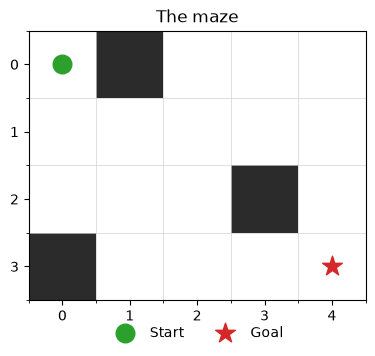

In [2]:
ROWS, COLS = 4, 5
# Note that these co-ordinates are considered as (y,x)
START = (0, 0)
GOAL = (3, 4)
WALLS = {(0, 1), (2, 3), (3,0)}   # one obstacle — try moving it or adding more!

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]      # up, down, left, right
ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]

def is_free(r, c):
    return 0 <= r < ROWS and 0 <= c < COLS and (r, c) not in WALLS

def show_maze(ax, robot_pos=None):
    grid = np.zeros((ROWS, COLS))
    for (wr, wc) in WALLS:
        grid[wr, wc] = 1
    ax.imshow(grid, cmap=ListedColormap(["white", "#2b2b2b"]), vmin=0, vmax=1)
    ax.scatter(START[1], START[0], c="tab:green", s=180, marker="o", zorder=3, label="Start")
    ax.scatter(GOAL[1], GOAL[0], c="tab:red", s=220, marker="*", zorder=3, label="Goal")
    if robot_pos is not None:
        ax.scatter(robot_pos[1], robot_pos[0], c="tab:blue", s=220, marker="o", zorder=4)

    # Set major ticks for cell labels (0, 1, 2, ...)
    ax.set_xticks(np.arange(COLS))
    ax.set_yticks(np.arange(ROWS))

    # Set minor ticks for grid lines *between* cells
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)

    # Draw grid lines on minor ticks
    ax.grid(which='minor', color="lightgray", linestyle='-', linewidth=0.5)
    # Hide major grid lines (which would otherwise appear in the middle of cells)
    ax.grid(which='major', color='white', linestyle='-', linewidth=0)

    # Ensure cells are square
    ax.set_aspect('equal')

fig, ax = plt.subplots(figsize=(4.5, 3.5))
show_maze(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
ax.set_title("The maze")
plt.show()

## 2. Build a training set with one simple rule

For every free cell, the label is: **the direction that gets you closer to
the goal, skipping any direction that's a wall.** That's the entire "teacher"
— no pathfinding algorithm involved.

In [3]:
def manhattan(r, c):
    return abs(r - GOAL[0]) + abs(c - GOAL[1])

def wall_sensor(r, c):
    """1 if that neighbor is a wall / off-grid, else 0 — one bit per direction."""
    bits = []
    for dr, dc in ACTIONS:
        nr, nc = r + dr, c + dc
        bits.append(0.0 if is_free(nr, nc) else 1.0)
    return bits

def featurize(r, c):
    return np.array([r / ROWS, c / COLS] + wall_sensor(r, c), dtype=np.float32)

# preference order used only to break ties among equally-good directions
PREFERENCE = [3, 1, 2, 0]  # RIGHT, DOWN, LEFT, UP

def best_direction(r, c):
    cur_d = manhattan(r, c)
    for ai in PREFERENCE:                       # prefer moves that get closer
        dr, dc = ACTIONS[ai]
        nr, nc = r + dr, c + dc
        if is_free(nr, nc) and manhattan(nr, nc) < cur_d:
            return ai
    for ai in PREFERENCE:                       # fallback: any move that doesn't get worse
        dr, dc = ACTIONS[ai]
        nr, nc = r + dr, c + dc
        if is_free(nr, nc) and manhattan(nr, nc) <= cur_d:
            return ai
    return None

X, y = [], []
cells_for_training = [] # Store cell coordinates to pair with X and y
for r in range(ROWS):
    for c in range(COLS):
        if is_free(r, c) and (r, c) != GOAL:
            a = best_direction(r, c)
            X.append(featurize(r, c))
            y.append(a)
            cells_for_training.append((r, c))

X = np.stack(X)
y = np.array(y)
print(f"Training samples: {X.shape[0]}  |  feature size: {X.shape[1]}")

# Modified print statement to include the feature vector and the one-hot target
for i, (feat_vec, action_idx, (r, c)) in enumerate(zip(X, y, cells_for_training)):
    target_output = np.zeros(len(ACTIONS), dtype=np.int32)
    target_output[action_idx] = 1
    print(f"  cell {(r, c)} (features: {feat_vec})  ->  Target Output: {target_output} ({ACTION_NAMES[action_idx]}) ")

Training samples: 16  |  feature size: 6
  cell (0, 0) (features: [0. 0. 1. 0. 1. 1.])  ->  Target Output: [0 1 0 0] (DOWN) 
  cell (0, 2) (features: [0.  0.4 1.  0.  1.  0. ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (0, 3) (features: [0.  0.6 1.  0.  0.  0. ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (0, 4) (features: [0.  0.8 1.  0.  0.  1. ])  ->  Target Output: [0 1 0 0] (DOWN) 
  cell (1, 0) (features: [0.25 0.   0.   0.   1.   0.  ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (1, 1) (features: [0.25 0.2  1.   0.   0.   0.  ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (1, 2) (features: [0.25 0.4  0.   0.   0.   0.  ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (1, 3) (features: [0.25 0.6  0.   1.   0.   0.  ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (1, 4) (features: [0.25 0.8  0.   0.   0.   1.  ])  ->  Target Output: [0 1 0 0] (DOWN) 
  cell (2, 0) (features: [0.5 0.  0.  1.  1.  0. ])  ->  Target Output: [0 0 0 1] (RIGHT) 
  cell (2, 1) (features: [0.

## 3. A tiny neural network, trained on that rule

Two hidden layers, plain classification, nothing fancy — this is the same
kind of network you've already seen in the deck.

In [4]:
class NavNet(nn.Module):
    def __init__(self, in_dim=6, hidden=16, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y).long()

model = NavNet()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 60
loss_history = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    logits = model(X_t)
    loss = loss_fn(logits, y_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

with torch.no_grad():
    train_acc = (model(X_t).argmax(dim=1) == y_t).float().mean().item()
print(f"Final loss: {loss_history[-1]:.4f}   |   accuracy: {train_acc*100:.0f}%")


Final loss: 0.0001   |   accuracy: 100%


## 4. Let the trained network drive

The network is now frozen. Starting at `START`, at every cell it looks at
its sensor reading and picks whichever direction scores highest (ignoring
any direction that's actually a wall) — exactly like the demo will show.

In [5]:
@torch.no_grad()
def navigate(model, max_steps=10):
    r, c = START
    path = [(r, c)]
    for _ in range(max_steps):
        if (r, c) == GOAL:
            break
        feat = torch.from_numpy(featurize(r, c)).unsqueeze(0)
        scores = model(feat).squeeze(0).numpy()
        valid = [ai for ai, (dr, dc) in enumerate(ACTIONS) if is_free(r + dr, c + dc)]
        chosen = max(valid, key=lambda ai: scores[ai])
        dr, dc = ACTIONS[chosen]
        r, c = r + dr, c + dc
        path.append((r, c))
    return path

path = navigate(model)
print("Robot's path:", path)
print("Steps taken:", len(path) - 1)


Robot's path: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (3, 4)]
Steps taken: 7


## 5. Split-screen demo: training on the left, driving on the right

The animation has two phases that play back to back in the same figure:
- **Left panel (all the way through):** the loss curve filling in as the
  network trains — this is what "the network updating itself" looks like.
- **Right panel:** stays on "Training..." while the left plays out, then
  the robot takes its steps one at a time once training is complete.

In [6]:
TRAIN_FRAMES = 30                                  # how many points of the loss curve to reveal
sample_idx = np.linspace(0, EPOCHS - 1, TRAIN_FRAMES).astype(int)
sampled_losses = [loss_history[i] for i in sample_idx]

DRIVE_FRAMES = len(path)                           # one frame per step, including the start
TOTAL_FRAMES = TRAIN_FRAMES + DRIVE_FRAMES

fig, (ax_loss, ax_maze) = plt.subplots(1, 2, figsize=(10, 4))

# --- left panel: loss curve ---
ax_loss.set_xlim(0, EPOCHS)
ax_loss.set_ylim(0, max(loss_history) * 1.1)
ax_loss.set_xlabel("Training step")
ax_loss.set_ylabel("Loss")
ax_loss.set_title("Neural network updating")
ax_loss.grid(True)
loss_line, = ax_loss.plot([], [], color="tab:purple", linewidth=2)

# --- right panel: maze ---
show_maze(ax_maze, robot_pos=START)
ax_maze.set_title("Training...")

def init():
    loss_line.set_data([], [])
    return (loss_line,)

def update(frame):
    if frame < TRAIN_FRAMES:
        xs = sample_idx[:frame + 1]
        ys = sampled_losses[:frame + 1]
        loss_line.set_data(xs, ys)
        ax_maze.set_title("Training...")
    else:
        loss_line.set_data(sample_idx, sampled_losses)     # keep full curve visible
        step = frame - TRAIN_FRAMES
        ax_maze.clear()
        show_maze(ax_maze, robot_pos=path[step])
        if step > 0:
            rows = [p[0] for p in path[:step + 1]]
            cols = [p[1] for p in path[:step + 1]]
            ax_maze.plot(cols, rows, color="tab:blue", linewidth=2, alpha=0.5, zorder=2)
        ax_maze.set_title(f"Driving — step {step} / {len(path) - 1}")
    return (loss_line,)

anim = animation.FuncAnimation(
    fig, update, frames=TOTAL_FRAMES, init_func=init, interval=200, blit=False
)
plt.close(fig)
HTML(anim.to_jshtml())

That's the full demo cell. A couple of easy live variations:

- Move `WALLS` to a different cell (or add a second one) and re-run from
  section 2 onward — the training examples change, and so does the path
  the robot ends up taking.
- Lower `EPOCHS` a lot (e.g. `10`) and re-run: the loss curve on the left
  won't flatten out, and you'll sometimes see the robot's driven path on
  the right take a wrong step — a nice hook for "what does it mean for a
  network to be undertrained?"
- To embed this as a GIF in your slide instead of a live notebook cell:
  `anim.save("maze_demo.gif", writer="pillow", fps=5)`